# 04 - Credit Loan Score

This notebook converts predicted default probabilities into a credit loan score. A higher score means lower estimated default risk. The output includes a probability of default, a score, risk bands, and a first decision label.

## 1. Setup

The notebook loads the processed modeling base, the selected fitted model, and score-scaling utilities.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from credit_default.config import MODELS_DIR, PROCESSED_DATA_DIR, TABLES_DIR  # noqa: E402
from credit_default.data import TARGET_COLUMN, load_credit_data  # noqa: E402
from credit_default.modeling import (  # noqa: E402
    RANDOM_STATE,
    load_modeling_base,
    positive_class_scores,
    split_features_target,
)
from credit_default.preprocessing import build_modeling_base  # noqa: E402
from credit_default.scoring import (  # noqa: E402
    DEFAULT_BASE_SCORE,
    DEFAULT_PDO,
    assign_credit_decision,
    assign_score_bands,
    build_score_scale,
    fit_score_band_edges,
    probability_to_score,
    score_to_probability,
    summarize_by_group,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('C:/Users/chris/OneDrive/Dokumente/projet/credit client')

## 2. Load Data and Model

The saved model artifact contains the selected estimator and any required preprocessing, so it can produce default probabilities directly from the modeling table.

In [3]:
modeling_path = PROCESSED_DATA_DIR / "credit_default_modeling_base.csv"
model_path = MODELS_DIR / "best_baseline_model.joblib"

if modeling_path.exists():
    modeling = load_modeling_base(modeling_path)
else:
    raw = load_credit_data()
    modeling = build_modeling_base(raw)
    modeling.to_csv(modeling_path, index=False)

if not model_path.exists():
    raise FileNotFoundError(
        "The selected model is missing. Run notebooks/03_modeling_baselines.ipynb first."
    )

model_artifact = joblib.load(model_path)
model_name = model_artifact["model_name"]
model_threshold = model_artifact["threshold"]
model = model_artifact["pipeline"]

print(f"Modeling shape: {modeling.shape[0]:,} rows x {modeling.shape[1]} columns")
print(f"Model used: {model_name}")
print(f"Validation-selected model threshold: {model_threshold:.3f}")

Modeling shape: 30,000 rows x 63 columns
Model used: catboost_plain
Validation-selected model threshold: 0.300


## 3. Score Scale

We use a simple odds-based score scale. The base score is linked to the portfolio default rate, and the points-to-double-odds parameter controls how quickly the score moves.

In [4]:
X, y = split_features_target(modeling)

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

base_default_rate = y_train_valid.mean()
score_scale = build_score_scale(
    base_default_rate=base_default_rate,
    base_score=DEFAULT_BASE_SCORE,
    pdo=DEFAULT_PDO,
)

score_scale_table = pd.DataFrame([score_scale])
display(score_scale_table)

# Sanity check: the conversion is reversible.
example_pd = pd.Series([0.05, 0.10, 0.22, 0.50, 0.70], name="default_probability")
example_score = probability_to_score(example_pd, score_scale).round(0).astype(int)
score_examples = pd.DataFrame(
    {
        "default_probability": example_pd,
        "credit_score": example_score,
        "recovered_probability": score_to_probability(example_score, score_scale),
    }
)
display(score_examples)

,base_score,pdo,base_default_rate,base_good_bad_odds,factor,offset
0,600.0000,50.0000,0.2212,3.5205,72.1348,509.2115


,default_probability,credit_score,recovered_probability
0,0.0500,722,0.0497
1,0.1000,668,0.0996
2,0.2200,601,0.2188
3,0.5000,509,0.5007
4,0.7000,448,0.7003


## 4. Score All Clients

Each client receives a predicted default probability and a corresponding credit score. The target is retained only for backtesting in this dataset.

In [5]:
predicted_default_probability = positive_class_scores(model, X)
credit_score = probability_to_score(predicted_default_probability, score_scale).round(0).astype(int)

scored = pd.DataFrame(
    {
        "ID": modeling["ID"],
        "predicted_default_probability": predicted_default_probability,
        "credit_score": credit_score,
        TARGET_COLUMN: modeling[TARGET_COLUMN],
    }
)

score_distribution = scored[["predicted_default_probability", "credit_score"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T
display(score_distribution)
display(scored.head())

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
predicted_default_probability,"30,000.0000",0.2210,0.1995,0.0187,0.0336,0.0456,0.0566,0.0877,0.1447,0.2640,0.5820,0.7080,0.8077,0.9278
credit_score,"30,000.0000",620.8018,82.4137,325.0000,406.0000,445.0000,485.0000,583.0000,637.0000,678.0000,712.0000,729.0000,752.0000,795.0000


,ID,predicted_default_probability,credit_score,default_payment_next_month
0,1,0.7505,430,1
1,2,0.3720,547,1
2,3,0.0928,674,0
3,4,0.1580,630,0
4,5,0.0884,677,0


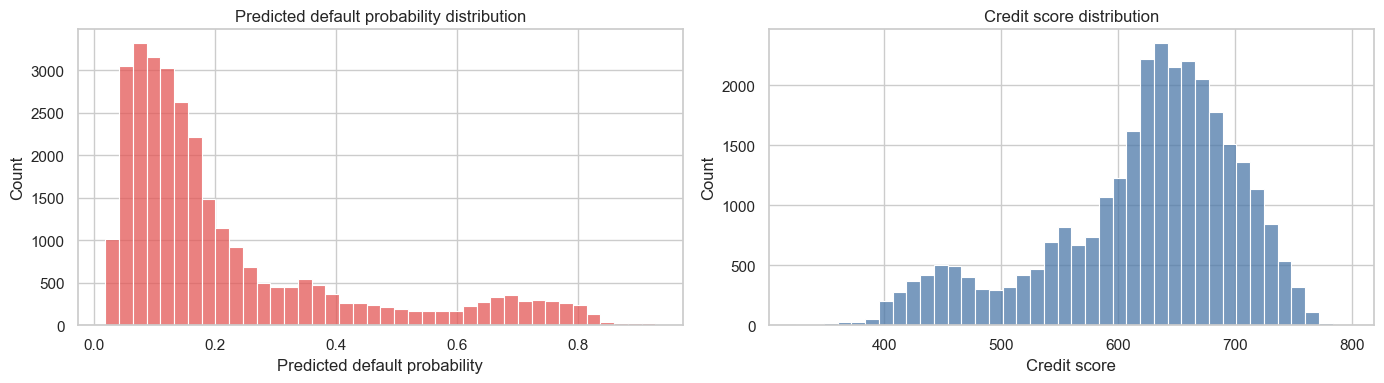

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(scored["predicted_default_probability"], bins=40, color="#E45756", ax=axes[0])
axes[0].set_title("Predicted default probability distribution")
axes[0].set_xlabel("Predicted default probability")

sns.histplot(scored["credit_score"], bins=40, color="#4C78A8", ax=axes[1])
axes[1].set_title("Credit score distribution")
axes[1].set_xlabel("Credit score")
plt.tight_layout()
plt.show()

## 5. Risk Bands

Score bands are fitted on development data and then applied to all clients. Bands are ordered from high risk to low risk.

In [7]:
train_valid_scores = scored.loc[y_train_valid.index, "credit_score"]
band_edges = fit_score_band_edges(train_valid_scores)

scored["risk_band"] = assign_score_bands(scored["credit_score"], band_edges)
scored["credit_decision"] = assign_credit_decision(scored["risk_band"])

band_edge_table = pd.DataFrame(
    {
        "cutoff_order": ["q20", "q40", "q60", "q80"],
        "credit_score_cutoff": band_edges,
    }
)
display(band_edge_table)

display(scored.head())

,cutoff_order,credit_score_cutoff
0,q20,558.0000
1,q40,622.0000
2,q60,653.0000
3,q80,688.0000


,ID,predicted_default_probability,credit_score,default_payment_next_month,risk_band,credit_decision
0,1,0.7505,430,1,E_very_high_risk,reject
1,2,0.3720,547,1,E_very_high_risk,reject
2,3,0.0928,674,0,B_low_risk,approve
3,4,0.1580,630,0,C_medium_risk,approve
4,5,0.0884,677,0,B_low_risk,approve


,risk_band,n,observed_defaults,observed_default_rate,mean_predicted_default_probability,mean_credit_score,min_credit_score,max_credit_score,share
0,E_very_high_risk,6034,3556,0.5893,0.5707,485.8295,325,558,0.2011
1,D_high_risk,6070,1504,0.2478,0.2314,596.9888,559,622,0.2023
2,C_medium_risk,6042,860,0.1423,0.1443,638.0225,623,653,0.2014
3,B_low_risk,5887,482,0.0819,0.0978,670.0260,654,688,0.1962
4,A_very_low_risk,5967,234,0.0392,0.0558,715.5122,689,795,0.1989


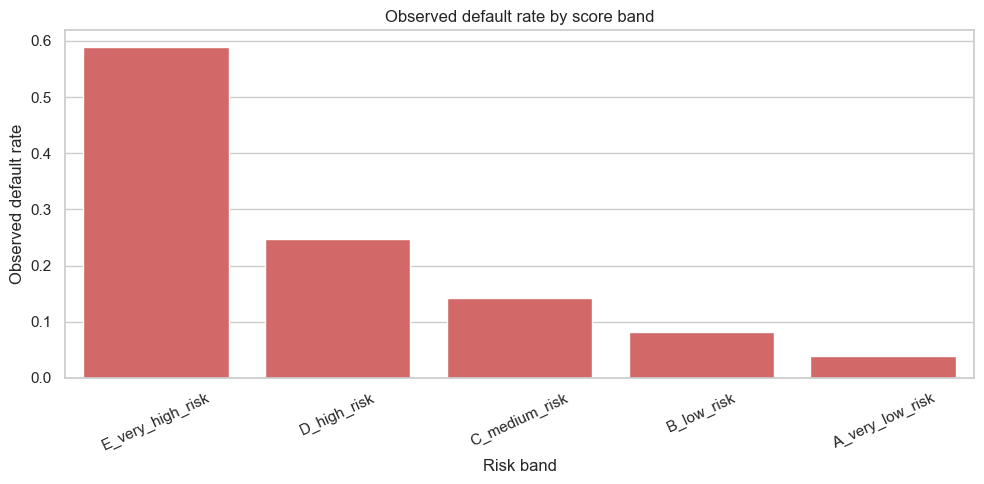

In [8]:
band_summary = summarize_by_group(
    scored,
    "risk_band",
    target_col=TARGET_COLUMN,
).sort_values("mean_credit_score")

display(band_summary)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=band_summary, x="risk_band", y="observed_default_rate", color="#E45756", ax=ax)
ax.set_title("Observed default rate by score band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Observed default rate")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

**Check.** A useful score should be monotonic: lower score bands should show higher observed default rates.

## 6. Initial Credit Policy

We map score bands to `approve`, `manual_review`, and `reject`. These cutoffs are simple first rules and could be adjusted later depending on business targets.

,credit_decision,n,observed_defaults,observed_default_rate,mean_predicted_default_probability,mean_credit_score,min_credit_score,max_credit_score,share
0,approve,17896,1576,0.0881,0.0995,674.3873,623,795,0.5965
1,manual_review,6070,1504,0.2478,0.2314,596.9888,559,622,0.2023
2,reject,6034,3556,0.5893,0.5707,485.8295,325,558,0.2011


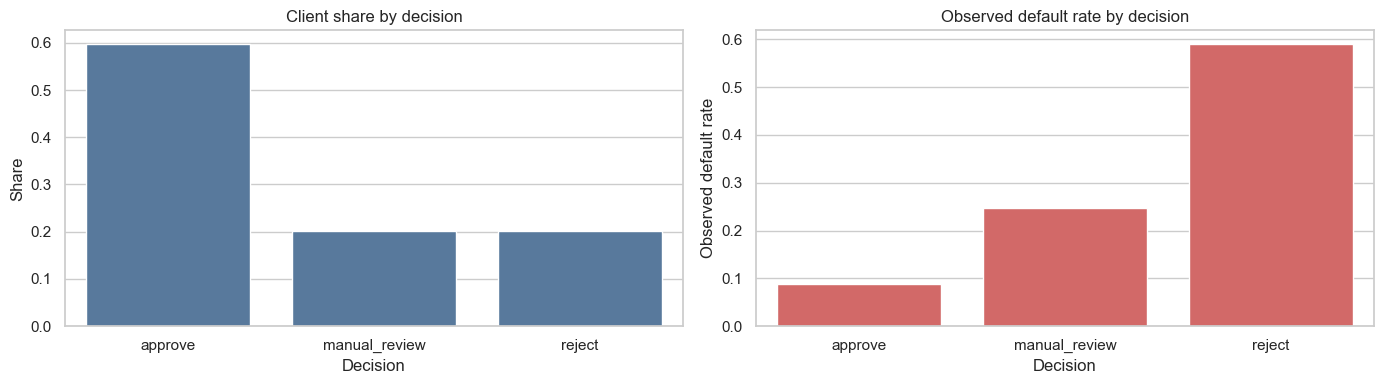

In [9]:
policy_summary = summarize_by_group(
    scored,
    "credit_decision",
    target_col=TARGET_COLUMN,
).sort_values("observed_default_rate")

display(policy_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=policy_summary, x="credit_decision", y="share", color="#4C78A8", ax=axes[0])
axes[0].set_title("Client share by decision")
axes[0].set_xlabel("Decision")
axes[0].set_ylabel("Share")

sns.barplot(data=policy_summary, x="credit_decision", y="observed_default_rate", color="#E45756", ax=axes[1])
axes[1].set_title("Observed default rate by decision")
axes[1].set_xlabel("Decision")
axes[1].set_ylabel("Observed default rate")
plt.tight_layout()
plt.show()

## 7. Link to the Classification Threshold

The model threshold can be converted into an equivalent score cutoff. This shows the connection between binary classification and score-based decisions.

In [10]:
score_cutoff_from_model_threshold = int(round(probability_to_score([model_threshold], score_scale)[0]))

threshold_equivalence = pd.DataFrame(
    [
        {
            "model_default_probability_threshold": model_threshold,
            "equivalent_credit_score_cutoff": score_cutoff_from_model_threshold,
            "interpretation": "If PD is above the threshold, the equivalent score is below the cutoff and the client is classified as high risk.",
        }
    ]
)
display(threshold_equivalence)

scored["classified_default_by_model_threshold"] = (
    scored["predicted_default_probability"] >= model_threshold
).astype(int)

classification_summary = (
    scored.groupby("classified_default_by_model_threshold", observed=False)[TARGET_COLUMN]
    .agg(n="size", observed_defaults="sum", observed_default_rate="mean")
    .reset_index()
)
classification_summary["share"] = classification_summary["n"] / len(scored)
display(classification_summary)

,model_default_probability_threshold,equivalent_credit_score_cutoff,interpretation
0,0.3000,570,"If PD is above the threshold, the equivalent s..."


,classified_default_by_model_threshold,n,observed_defaults,observed_default_rate,share
0,0,23290,2860,0.1228,0.7763
1,1,6710,3776,0.5627,0.2237


## 8. Final Scored File

The final table keeps client ID, selected business fields, predicted default probability, credit score, risk band, decision label, and observed target for backtesting.

In [11]:
raw = load_credit_data()[["ID", "LIMIT_BAL", "AGE", "PAY_0", TARGET_COLUMN]]
final_scores = scored.drop(columns=[TARGET_COLUMN]).merge(raw, on="ID", how="left")

# Column order for the scoring deliverable.
final_scores = final_scores[
    [
        "ID",
        "LIMIT_BAL",
        "AGE",
        "PAY_0",
        "predicted_default_probability",
        "credit_score",
        "risk_band",
        "credit_decision",
        "classified_default_by_model_threshold",
        TARGET_COLUMN,
    ]
]

display(final_scores.head(10))

,ID,LIMIT_BAL,AGE,PAY_0,predicted_default_probability,credit_score,risk_band,credit_decision,classified_default_by_model_threshold,default_payment_next_month
0,1,20000,24,2,0.7505,430,E_very_high_risk,reject,1,1
1,2,120000,26,-1,0.3720,547,E_very_high_risk,reject,1,1
2,3,90000,34,0,0.0928,674,B_low_risk,approve,0,0
3,4,50000,37,0,0.1580,630,C_medium_risk,approve,0,0
4,5,50000,57,-1,0.0884,677,B_low_risk,approve,0,0
5,6,50000,37,0,0.1935,612,D_high_risk,manual_review,0,0
6,7,500000,29,0,0.0911,675,B_low_risk,approve,0,0
7,8,100000,23,0,0.1600,629,C_medium_risk,approve,0,0
8,9,140000,28,0,0.1920,613,D_high_risk,manual_review,0,0
9,10,20000,35,-2,0.1435,638,C_medium_risk,approve,0,0


In [12]:
scored_path = PROCESSED_DATA_DIR / "credit_default_scored.csv"
score_scale_path = TABLES_DIR / "credit_score_scale.csv"
band_edges_path = TABLES_DIR / "credit_score_band_edges.csv"
band_summary_path = TABLES_DIR / "credit_score_band_summary.csv"
policy_summary_path = TABLES_DIR / "credit_score_policy_summary.csv"
threshold_equivalence_path = TABLES_DIR / "credit_score_threshold_equivalence.csv"

final_scores.to_csv(scored_path, index=False)
score_scale_table.to_csv(score_scale_path, index=False)
band_edge_table.to_csv(band_edges_path, index=False)
band_summary.to_csv(band_summary_path, index=False)
policy_summary.to_csv(policy_summary_path, index=False)
threshold_equivalence.to_csv(threshold_equivalence_path, index=False)

exports = pd.DataFrame(
    [
        {"artifact": "scored clients", "path": scored_path.relative_to(PROJECT_ROOT), "rows": len(final_scores)},
        {"artifact": "score scale", "path": score_scale_path.relative_to(PROJECT_ROOT), "rows": len(score_scale_table)},
        {"artifact": "band edges", "path": band_edges_path.relative_to(PROJECT_ROOT), "rows": len(band_edge_table)},
        {"artifact": "band summary", "path": band_summary_path.relative_to(PROJECT_ROOT), "rows": len(band_summary)},
        {"artifact": "policy summary", "path": policy_summary_path.relative_to(PROJECT_ROOT), "rows": len(policy_summary)},
        {"artifact": "threshold equivalence", "path": threshold_equivalence_path.relative_to(PROJECT_ROOT), "rows": len(threshold_equivalence)},
    ]
)
display(exports)

,artifact,path,rows
0,scored clients,data\processed\credit_default_scored.csv,30000
1,score scale,reports\tables\credit_score_scale.csv,1
2,band edges,reports\tables\credit_score_band_edges.csv,4
3,band summary,reports\tables\credit_score_band_summary.csv,5
4,policy summary,reports\tables\credit_score_policy_summary.csv,3
5,threshold equivalence,reports\tables\credit_score_threshold_equivale...,1


## 9. Summary

The scoring workflow turns the model into an operational credit score with transparent bands and decision labels.